Open this notebook in Jupyter or upload it to Colab to run it.

# Cereal Nutrition and Ratings

## Overview:


This notebook explores nutritional values, ratings, manufacturers, and hot-versus-cold categories in a cereal dataset.

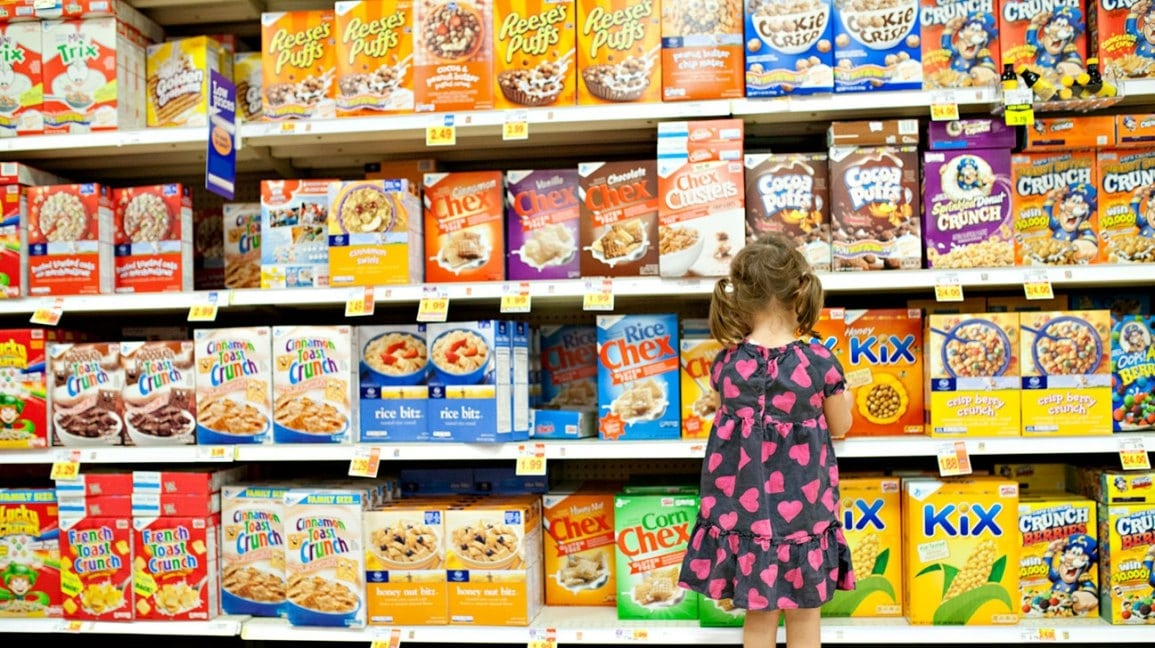


### Getting Started: 
Download the cereal data with the cell below, then use pandas, NumPy, Matplotlib, and/or seaborn to explore it.

These libraries provide the data-wrangling, plotting, and statistical operations used in the notebook.

You can use/read their respective documentation in the links below (only if you need too, it's not required for the lab):

*   Seaborn [Documentation]("https://seaborn.pydata.org/tutorial.html")
*   Matplotlib [Documentation]("https://matplotlib.org/stable/api/index.html")
*   Numpy [Documentation]("https://numpy.org/doc/1.23/user/index.html#user")
*   Pandas [Documentation]("https://pandas.pydata.org/docs/user_guide/index.html#user-guide")







In [1]:
!wget https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cereal.csv

--2023-02-18 18:54:11--  https://raw.githubusercontent.com/porterjenkins/cs180-intro-data-science/master/data/cereal.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4985 (4.9K) [text/plain]
Saving to: ‘cereal.csv’

cereal.csv          100%[===================>]   4.87K  --.-KB/s    in 0s      

2023-02-18 18:54:12 (30.3 MB/s) - ‘cereal.csv’ saved [4985/4985]



## Exercise 1: Protein Powder
Carbs, fats and proteins are the three primary macro nutrients. Create a figure plotting the distribution of each of these macro nutrients together (i.e., three distributions on a single plot). Make sure to provide a legend.

In [2]:
# Enter all of your code for exercise 1 here. Feel free to add more cells if you need to:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv("cereal.csv")
data.head()

,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
1,100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
2,All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
4,Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


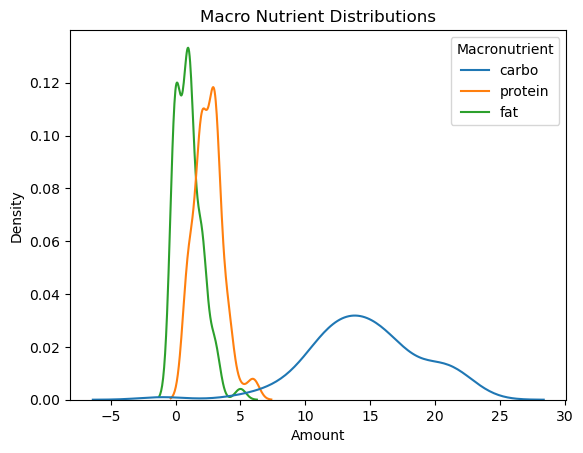

In [4]:
macro_df = data[['carbo', 'protein', 'fat']]
macro_df.head()
# sns.stripplot(data=macro_df)
macro_plot = sns.kdeplot(data=macro_df)
macro_plot.set_xlabel('Amount')
macro_plot.legend_.set_title('Macronutrient')
macro_plot.set_title("Macro Nutrient Distributions")
plt.show()

## Exercise 2: Sugar Daddy
Get a list of the top 5 most sugary cereals and the 5 least sugary cereals.

In [5]:
# Enter all of your code for exercise 2 here. Feel free to add more cells if you need to:
sugar_sort_descending = data[['name', 'sugars']].sort_values(by=['sugars'], ascending=False)
sugar_sort_descending.head(5)

,name,sugars
66,Smacks,15
30,Golden Crisp,15
70,Total Raisin Bran,14
52,Post Nat. Raisin Bran,14
6,Apple Jacks,14


In [6]:
sugar_sort_ascending = data[['name', 'sugars']].sort_values(by='sugars', ascending=True)
sugar_sort_ascending.head(5)

,name,sugars
57,Quaker Oatmeal,-1
55,Puffed Wheat,0
20,Cream of Wheat (Quick),0
63,Shredded Wheat,0
3,All-Bran with Extra Fiber,0


## Exercise 3: Cereal Killer
Get a list of the top 5 highest rated and lowest rated cereals.

In [7]:
# Enter all of your code for exercise 3 here. Feel free to add more cells if you need to:
data[['name','rating']].sort_values(by='rating', ascending=False).head(5)

,name,rating
3,All-Bran with Extra Fiber,93.704912
64,Shredded Wheat 'n'Bran,74.472949
65,Shredded Wheat spoon size,72.801787
0,100% Bran,68.402973
63,Shredded Wheat,68.235885


In [8]:
data[['name','rating']].sort_values(by='rating', ascending=True).head(5)

,name,rating
10,Cap'n'Crunch,18.042851
12,Cinnamon Toast Crunch,19.823573
35,Honey Graham Ohs,21.871292
18,Count Chocula,22.396513
14,Cocoa Puffs,22.736446


## Exercise 4: America
Quantify the relationship between sugar and ratings. 

Make a plot to visualize this relationship. Superimpose a best fit line (with seaborn) to describe the relationship. It may be helpful to look at the [seaborn regplot documentation]("https://seaborn.pydata.org/generated/seaborn.regplot.html").

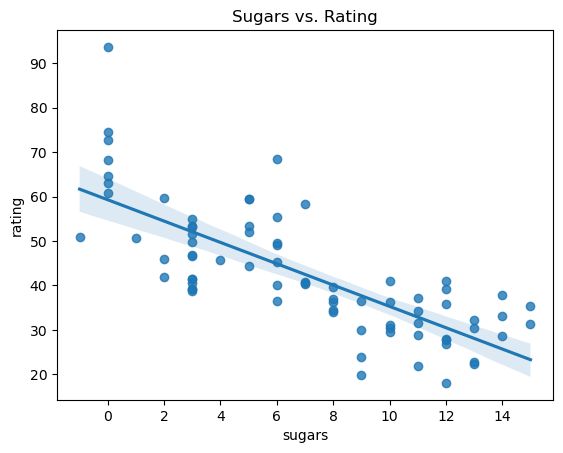

In [9]:
# Make the plot for the data visualization and line of best fit here:
sugar_rating = sns.regplot(data = data, x = 'sugars', y = 'rating')
sugar_rating.set_title('Sugars vs. Rating')
plt.show()


Calculate a correlation statistic describing the relationship between sugar and ratings  (i.e., r or r squared).

In [10]:
# Calculate the statistic using this cell:
R = data['sugars'].corr(data['rating'])
print(f"R-value: {R}")

R-value: -0.7596746584301076


Write a statement in plain English interpreting this statistic.

> With a correlation coefficient, $R$, of approximately $-0.7597$, the ratings of cereals in this dataset are negatively linearly correlated with the amount of sugars in each cereal. 

> That is, on average, the higher the amount of sugars, the lower the estimated rating is.

## Exercise 5: America Part 2
Make five plots comparing the relationships of carbo, sugars, calories, protein, and fat with rating.

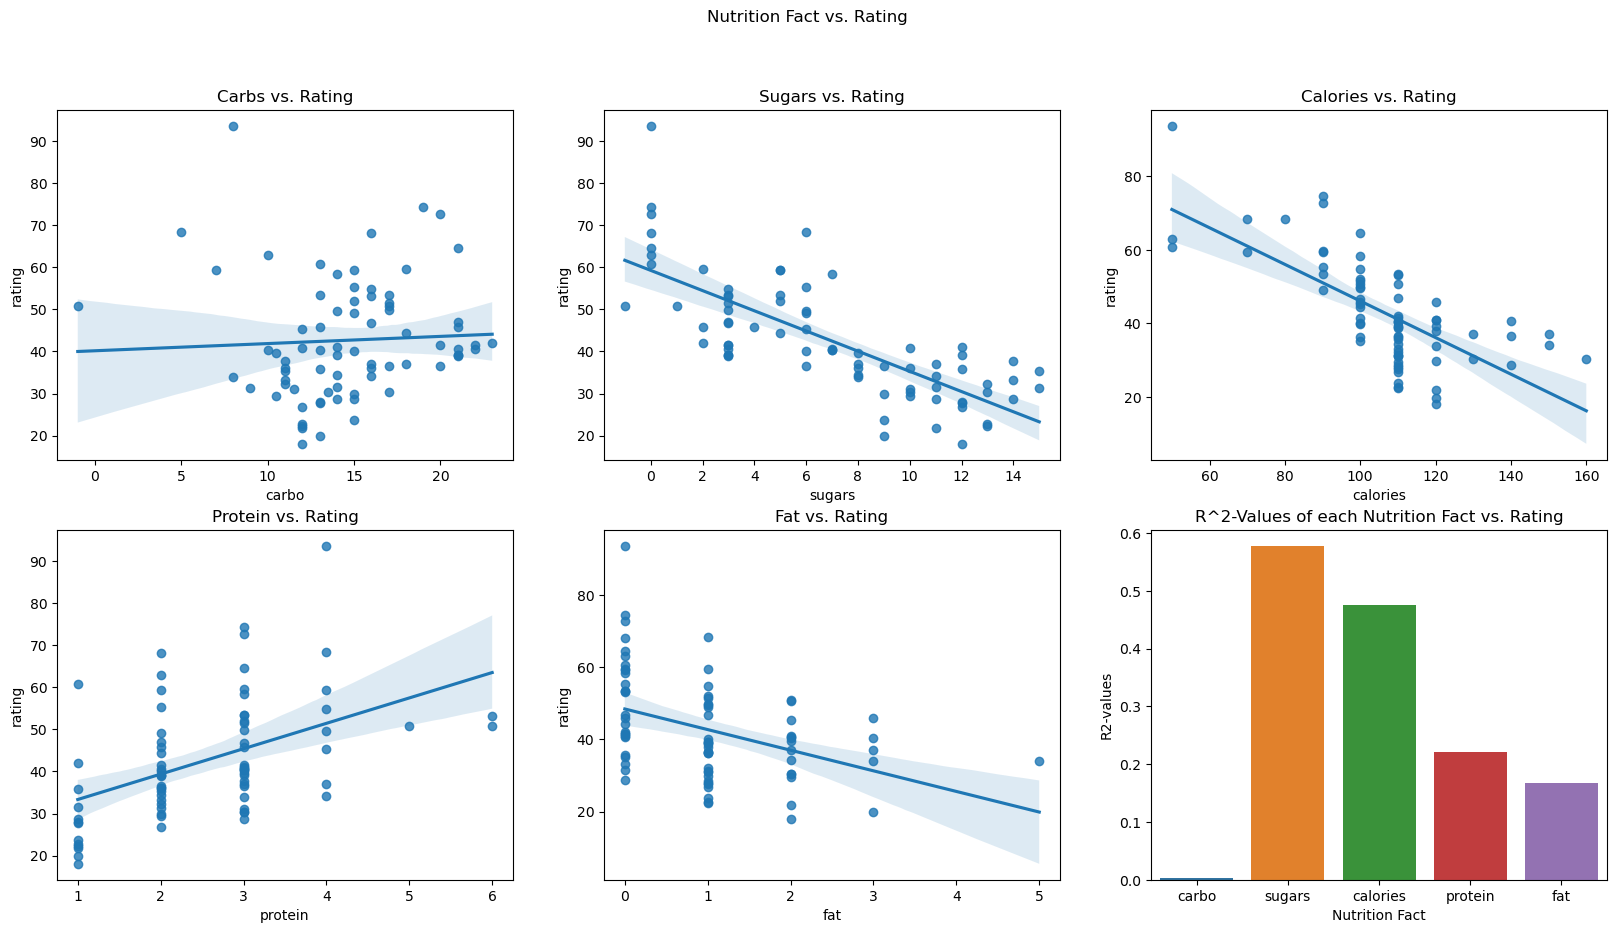

In [11]:
# Write your code to compare the various variables with rating below:
fig, axes = plt.subplots(2,3, figsize=(20,10))
fig.suptitle('Nutrition Fact vs. Rating')
sns.regplot(ax = axes[0,0], data = data, x = 'carbo', y = 'rating').title.set_text('Carbs vs. Rating')
sns.regplot(ax = axes[0,1], data = data, x = 'sugars', y = 'rating').title.set_text('Sugars vs. Rating')
sns.regplot(ax = axes[0,2], data = data, x = 'calories', y = 'rating').title.set_text('Calories vs. Rating')
sns.regplot(ax = axes[1,0], data = data, x = 'protein', y = 'rating').title.set_text('Protein vs. Rating')
sns.regplot(ax = axes[1,1], data = data, x = 'fat', y = 'rating').title.set_text('Fat vs. Rating')


Rcarbo = data['carbo'].corr(data['rating'])**2
Rsugar = data['sugars'].corr(data['rating'])**2
Rcalories = data['calories'].corr(data['rating'])**2
Rprotein = data['protein'].corr(data['rating'])**2
Rfat = data['fat'].corr(data['rating'])**2

Corr = {'R2-values': [Rcarbo, Rsugar, Rcalories, Rprotein, Rfat], 'Nutrition Fact': ['carbo','sugars','calories','protein','fat']}
CorrDf = pd.DataFrame(Corr)
sns.barplot(data=CorrDf, x='Nutrition Fact', y='R2-values').title.set_text('R^2-Values of each Nutrition Fact vs. Rating')

plt.show()

Of the variables carbo, sugars, calories, protein, and fat, which has the strongest relationship with rating? Justify your answer.

> As the $R^2$ correlation value of sugars vs. rating is the highest, sugar has the strongest relationship with rating.

## Exercise 6: Preparing for Mt. Everest
Do the same as you did with exercise 5, but instead compare carbo, sugars, protein, and fat with calories.

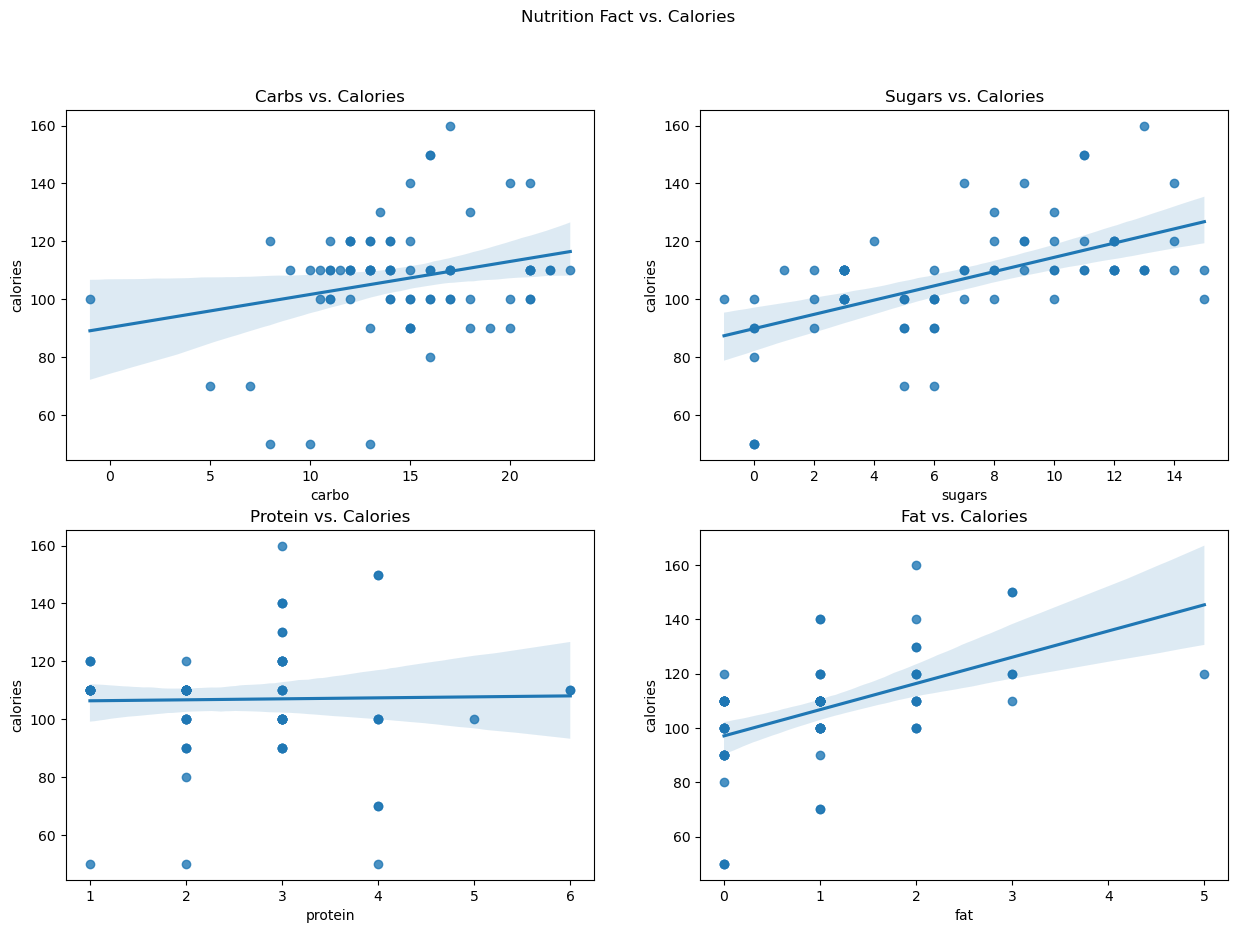

In [12]:
# Write your code to compare the various variables with calories below:
fig, axes = plt.subplots(2,2, figsize=(15,10))
fig.suptitle('Nutrition Fact vs. Calories')
sns.regplot(ax = axes[0,0], data = data, x = 'carbo',y = 'calories').title.set_text('Carbs vs. Calories')
sns.regplot(ax = axes[0,1], data = data, x = 'sugars',y = 'calories').title.set_text('Sugars vs. Calories')
sns.regplot(ax = axes[1,0], data = data, x = 'protein',y = 'calories').title.set_text('Protein vs. Calories')
sns.regplot(ax = axes[1,1], data = data, x = 'fat',y = 'calories').title.set_text('Fat vs. Calories')

plt.show()

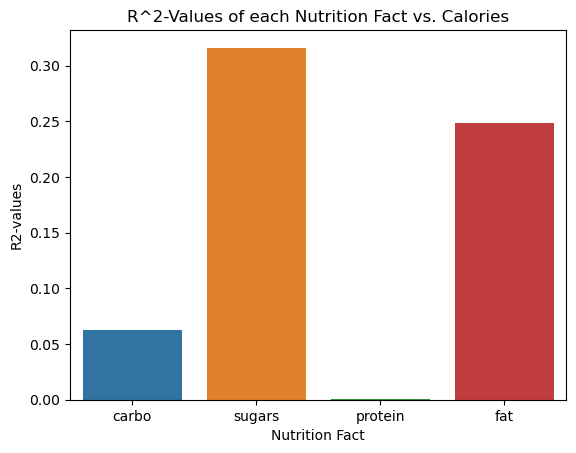

In [13]:
Rcarbo = data['carbo'].corr(data['calories'])**2
Rsugar = data['sugars'].corr(data['calories'])**2
Rprotein = data['protein'].corr(data['calories'])**2
Rfat = data['fat'].corr(data['calories'])**2

Corr = {'R2-values': [Rcarbo, Rsugar, Rprotein, Rfat], 'Nutrition Fact': ['carbo','sugars','protein','fat']}
CorrDf = pd.DataFrame(Corr)
sns.barplot(data=CorrDf, x='Nutrition Fact', y='R2-values').title.set_text('R^2-Values of each Nutrition Fact vs. Calories')

plt.show()

Of the variables carbo, sugars, protein, and fat, which has the strongest relationship with calories? Justify your answer.

> As the $R^2$ correlation value of sugars vs. calories is the highest, sugar has the strongest relationship with calories.

## Exercise 7: It’s Hot and It's Cold
The type column has two values: H='hot' and C='cold'. What is the average rating of each type?

In [14]:
# Write your code to get the average rating by type of cereal below:
hots = data[data['type'] == 'H']
colds = data[data['type'] == 'C']
hots_average_rating = hots['rating'].mean()
colds_average_rating = colds['rating'].mean()

print(f"The average rating for Hot cereals is {hots_average_rating}")
print(f"The average rating for Cold cereals is {colds_average_rating}")

The average rating for Hot cereals is 56.73770833333334
The average rating for Cold cereals is 42.095218364864856


## Exercise 8: Captain Crunch the Numbers
Provide one additional insight from this dataset that you found interesting. Create at least one figure and explain why the figure was interesting to you.

0                     100% Bran
20       Cream of Wheat (Quick)
63               Shredded Wheat
64       Shredded Wheat 'n'Bran
65    Shredded Wheat spoon size
68      Strawberry Fruit Wheats
Name: name, dtype: object


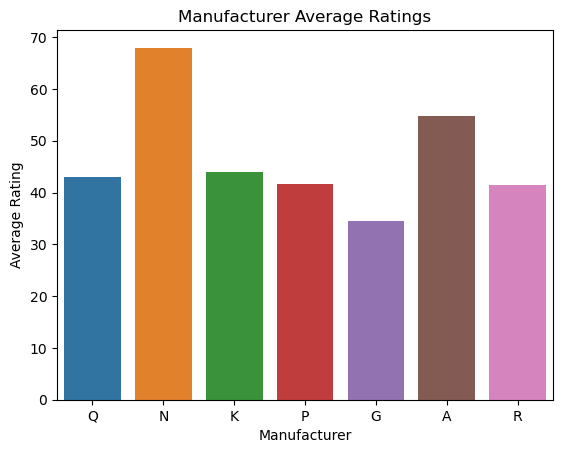

In [15]:
# Create the extra plot below:
mfr_list = [*set(data['mfr'].tolist())]
mfr_means = {'Manufacturer': ['Q','N','K','P','G','A','R'],
             'Average Rating': 
            [data[data['mfr']=='Q']['rating'].mean(),
             data[data['mfr']=='N']['rating'].mean(),
             data[data['mfr']=='K']['rating'].mean(),
             data[data['mfr']=='P']['rating'].mean(),
             data[data['mfr']=='G']['rating'].mean(),
             data[data['mfr']=='A']['rating'].mean(),
             data[data['mfr']=='R']['rating'].mean(),]}
mfr_df = pd.DataFrame(mfr_means)
print(data[data['mfr']=='N']['name'])
sns.barplot(data=mfr_df, x='Manufacturer', y='Average Rating').title.set_text('Manufacturer Average Ratings')
plt.show()

> Manufacturer $N$ has the higheset average rating for their cereals. The cereals from this manufacturer, however, seem to be the most generic and conventionally undesirable cereals.

> Simple is better, I guess?